In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc, f1_score, balanced_accuracy_score, log_loss
from sklearn.preprocessing import StandardScaler
from scipy.stats import wilcoxon
from scipy.stats import friedmanchisquare
import warnings
warnings.simplefilter('ignore')

## 1 Comparaison de méthodes de ML
Nous fournissons trois datasets : heart.csv, segment.csv et vehicle.csv.
Le premier dataset est un problème de classification binaire, qui vise à prédire la présence d’une maladie cardiaque à l’aide de 13 caractéristiques cliniques. Le deuxième dataset est un problème de classification multi-classe, qui comprend des imagettes segmentées à partir d’images de scènes naturelles en extérieur et qui vise à prédire ce qu’elles représentent à partir de caractéristiques calculées sur les pixels. Le troisième dataset est un problème de classification multi-classe, qui vise à prédire le type de véhicules à partir de caractéristiques descriptives de leur silhouette.

1. Chargez, analysez et donnez une brève description des données : dimensions, nombre de
données, nombre de classes, distributions des classes, etc.

In [4]:
df1 = pd.read_csv('heart.csv', sep=',')
df2 = pd.read_csv('segment.csv', sep=',')
df3 = pd.read_csv('vehicle.csv', sep=',')

### df1 - heart.csv

In [5]:
df1.describe()

,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [6]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   270 non-null    int64  
 1   sex                                   270 non-null    int64  
 2   chest                                 270 non-null    int64  
 3   resting_blood_pressure                270 non-null    int64  
 4   serum_cholestoral                     270 non-null    int64  
 5   fasting_blood_sugar                   270 non-null    int64  
 6   resting_electrocardiographic_results  270 non-null    int64  
 7   maximum_heart_rate_achieved           270 non-null    int64  
 8   exercise_induced_angina               270 non-null    int64  
 9   oldpeak                               270 non-null    float64
 10  slope                                 270 non-null    int64  
 11  number_of_major_ves

In [7]:
y1 = df1['class']
y1 = y1.map({'present': 1, 'absent': 0})
X1 = df1.drop('class', axis =1)

df1.groupby(['class'])['class'].count()

,class
class,
absent,150
present,120


In [8]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42, stratify=y1)

print(f"Train: {len(y_train1)/len(y1)*100:.2f}% = {len(y_train1)}")
print(f"Test: {len(y_test1)/len(y1)*100:.2f}% = {len(y_test1)}")

sc = StandardScaler(with_mean=True , with_std=True)
sc = sc.fit(X_train1)
Xa_n1 = sc.transform(X_train1)
Xt_n1 = sc.transform(X_test1)

Train: 80.00% = 216
Test: 20.00% = 54


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    We can see that this dataset has few rows (270), but also only 14 features and 2 classes. The "absent" class has a slightly larger number of examples, but we can say that there is a balanced division, which makes model fitting easier. The features have quite different scales, so data normalization was performed.
  </p>
</div>

### df2 - segment.csv

In [9]:
df2.describe()

,region.centroid.col,region.centroid.row,region.pixel.count,short.line.density.5,short.line.density.2,vedge.mean,vegde.sd,hedge.mean,hedge.sd,intensity.mean,rawred.mean,rawblue.mean,rawgreen.mean,exred.mean,exblue.mean,exgreen.mean,value.mean,saturation.mean,hue.mean
count,2310.000000,2310.000000,2310.0,2310.000000,2310.000000,2310.000000,2310.000000,2310.000000,2.310000e+03,2310.000000,2310.000000,2310.000000,2310.000000,2310.000000,2310.000000,2310.000000,2310.000000,2310.000000,2310.000000
mean,124.913853,123.417316,9.0,0.014334,0.004714,1.893940,5.709320,2.424723,8.243692e+00,37.051595,32.821309,44.187877,34.145601,-12.690860,21.408850,-8.717989,45.137468,0.426893,-1.362897
std,72.956532,57.483851,0.0,0.040154,0.024234,2.698909,44.846453,3.610083,5.881153e+01,38.176410,35.036776,43.527458,36.364774,11.583561,19.571819,11.551628,42.921761,0.228309,1.545336
min,1.000000,11.000000,9.0,0.000000,0.000000,0.000000,0.000000,0.000000,-1.589460e-08,0.000000,0.000000,0.000000,0.000000,-49.666700,-12.444400,-33.888900,0.000000,0.000000,-3.044180
25%,62.000000,81.000000,9.0,0.000000,0.000000,0.722221,0.355555,0.777780,4.216372e-01,7.296300,7.000000,9.555560,6.027778,-18.555600,4.138888,-16.777800,11.555600,0.284235,-2.188057
50%,121.000000,122.000000,9.0,0.000000,0.000000,1.222220,0.833333,1.444440,9.629630e-01,21.592600,19.555600,27.666700,20.333300,-10.888900,19.666700,-10.888900,28.666700,0.374803,-2.051200
75%,189.000000,172.000000,9.0,0.000000,0.000000,2.166670,1.806370,2.555560,2.183272e+00,53.213000,47.333300,64.888900,46.500025,-4.222220,35.777800,-3.222220,64.888900,0.540123,-1.562305
max,254.000000,251.000000,9.0,0.333333,0.222222,29.222200,991.718000,44.722200,1.386330e+03,143.444000,137.111000,150.889000,142.556000,9.888890,82.000000,24.666700,150.889000,1.000000,2.912480


In [10]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2310 entries, 0 to 2309
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   region.centroid.col   2310 non-null   int64  
 1   region.centroid.row   2310 non-null   int64  
 2   region.pixel.count    2310 non-null   int64  
 3   short.line.density.5  2310 non-null   float64
 4   short.line.density.2  2310 non-null   float64
 5   vedge.mean            2310 non-null   float64
 6   vegde.sd              2310 non-null   float64
 7   hedge.mean            2310 non-null   float64
 8   hedge.sd              2310 non-null   float64
 9   intensity.mean        2310 non-null   float64
 10  rawred.mean           2310 non-null   float64
 11  rawblue.mean          2310 non-null   float64
 12  rawgreen.mean         2310 non-null   float64
 13  exred.mean            2310 non-null   float64
 14  exblue.mean           2310 non-null   float64
 15  exgreen.mean         

In [11]:
y2 = df2['class']
y2 = y2.map({'path': 0, 'foliage': 1, 'sky': 2, 'grass': 3, 'brickface': 4, 'cement': 5, 'window': 6})
X2 = df2.drop('class', axis =1)

df2.groupby(['class'])['class'].count()

,class
class,
brickface,330
cement,330
foliage,330
grass,330
path,330
sky,330
window,330


In [12]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)

print(f"Train: {len(y_train2)/len(y2)*100:.2f}% = {len(y_train2)}")
print(f"Test: {len(y_test2)/len(y2)*100:.2f}% = {len(y_test2)}")

sc = sc.fit(X_train2)
Xa_n2 = sc.transform(X_train2)
Xt_n2 = sc.transform(X_test2)

Train: 80.00% = 1848
Test: 20.00% = 462


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    This second dataset has a much larger number of classes (7), but the amount of data (2310) and features (19) are also higher, which could enable good classification. The classes are perfectly balanced, with 330 examples in each.
  </p>
</div>

### df3 - vehicle.csv

In [13]:
df3.describe()

,COMPACTNESS,CIRCULARITY,DISTANCE_CIRCULARITY,RADIUS_RATIO,PR.AXIS_ASPECT_RATIO,MAX.LENGTH_ASPECT_RATIO,SCATTER_RATIO,ELONGATEDNESS,PR.AXIS_RECTANGULARITY,MAX.LENGTH_RECTANGULARITY,SCALED_VARIANCE_MAJOR,SCALED_VARIANCE_MINOR,SCALED_RADIUS_OF_GYRATION,SKEWNESS_ABOUT_MAJOR,SKEWNESS_ABOUT_MINOR,KURTOSIS_ABOUT_MAJOR,KURTOSIS_ABOUT_MINOR,HOLLOWS_RATIO
count,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.00000,846.000000,846.000000,846.000000,846.000000,846.000000
mean,93.678487,44.861702,82.088652,168.940898,61.693853,8.567376,168.839243,40.933806,20.582742,147.998818,188.625296,439.911348,174.70331,72.462175,6.377069,12.599291,188.932624,195.632388
std,8.234474,6.169866,15.771533,33.472183,7.888251,4.601217,33.244978,7.811560,2.592138,14.515652,31.394837,176.692614,32.54649,7.486974,4.918353,8.931240,6.163949,7.438797
min,73.000000,33.000000,40.000000,104.000000,47.000000,2.000000,112.000000,26.000000,17.000000,118.000000,130.000000,184.000000,109.00000,59.000000,0.000000,0.000000,176.000000,181.000000
25%,87.000000,40.000000,70.000000,141.000000,57.000000,7.000000,146.250000,33.000000,19.000000,137.000000,167.000000,318.250000,149.00000,67.000000,2.000000,5.000000,184.000000,190.250000
50%,93.000000,44.000000,80.000000,167.000000,61.000000,8.000000,157.000000,43.000000,20.000000,146.000000,178.500000,364.000000,173.00000,71.500000,6.000000,11.000000,188.000000,197.000000
75%,100.000000,49.000000,98.000000,195.000000,65.000000,10.000000,198.000000,46.000000,23.000000,159.000000,217.000000,587.000000,198.00000,75.000000,9.000000,19.000000,193.000000,201.000000
max,119.000000,59.000000,112.000000,333.000000,138.000000,55.000000,265.000000,61.000000,29.000000,188.000000,320.000000,1018.000000,268.00000,135.000000,22.000000,41.000000,206.000000,211.000000


In [14]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   COMPACTNESS                846 non-null    int64 
 1   CIRCULARITY                846 non-null    int64 
 2   DISTANCE_CIRCULARITY       846 non-null    int64 
 3   RADIUS_RATIO               846 non-null    int64 
 4   PR.AXIS_ASPECT_RATIO       846 non-null    int64 
 5   MAX.LENGTH_ASPECT_RATIO    846 non-null    int64 
 6   SCATTER_RATIO              846 non-null    int64 
 7   ELONGATEDNESS              846 non-null    int64 
 8   PR.AXIS_RECTANGULARITY     846 non-null    int64 
 9   MAX.LENGTH_RECTANGULARITY  846 non-null    int64 
 10  SCALED_VARIANCE_MAJOR      846 non-null    int64 
 11  SCALED_VARIANCE_MINOR      846 non-null    int64 
 12  SCALED_RADIUS_OF_GYRATION  846 non-null    int64 
 13  SKEWNESS_ABOUT_MAJOR       846 non-null    int64 
 14  SKEWNESS_A

In [15]:
y3 = df3['Class']
y3 = y3.map({'bus': 0, 'opel': 1, 'saab': 2, 'van': 3})
X3 = df3.drop('Class', axis =1)

df3.groupby(['Class'])['Class'].count()

,Class
Class,
bus,218
opel,212
saab,217
van,199


In [16]:
X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size=0.2, random_state=42, stratify=y3)

print(f"Train: {len(y_train3)/len(y3)*100:.2f}% = {len(y_train3)}")
print(f"Test: {len(y_test3)/len(y3)*100:.2f}% = {len(y_test3)}")

sc = sc.fit(X_train3)
Xa_n3 = sc.transform(X_train3)
Xt_n3 = sc.transform(X_test3)

Train: 79.91% = 676
Test: 20.09% = 170


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    In this last dataset, with 846 examples and 18 features, the 4 classes also have a distribution that is quite close.
  </p>
</div>

## 2. Sélectionnez 3 méthodes de ML :
- un modèle de régression logistique
- un SVM de votre choix
- une autre méthode de classification de votre choix, disponible dans sklearn et que vous
avez déjà utilisée en T3A ou en Apprentissage Automatique au premier semestre

### Model 1 - Logistic Regression

In [17]:
XTrains = [Xa_n1, Xa_n2, Xa_n3]
yTrains = [y_train1, y_train2, y_train3]

In [18]:
grid={"C":[0.1, 1, 10, 100], "penalty":["l1","l2"]} # l1 lasso l2 ridge
model1=LogisticRegression()
LRs = []

for i in range(3):
    model1x=GridSearchCV(model1,grid,cv=3)
    model1x.fit(XTrains[i],yTrains[i])
    LRs.append(model1x)

    print(f"Best parameters for dataset {i}: {model1x.best_params_}")
    print(f"Accuracy: {model1x.best_score_*100:.2f}%\n")

Best parameters for dataset 0: {'C': 0.1, 'penalty': 'l2'}
Accuracy: 85.65%

Best parameters for dataset 1: {'C': 100, 'penalty': 'l2'}
Accuracy: 94.53%

Best parameters for dataset 2: {'C': 10, 'penalty': 'l2'}
Accuracy: 77.37%



### Model 2 - SVM

In [19]:
grid = {'C':[0.001, 0.01, 0.1, 1, 10, 100, 1000], 'degree':[1, 2, 3, 4, 5]}
model2 = SVC(kernel="poly")
SVMs = []

for i in range(3):
    model2x = GridSearchCV(model2,grid,cv=3)
    model2x.fit(XTrains[i],yTrains[i])
    SVMs.append(model2x)

    print(f"Best parameters for dataset {i}: {model2x.best_params_}")
    print(f"Accuracy: {model2x.best_score_*100:.2f}%\n")

Best parameters for dataset 0: {'C': 0.1, 'degree': 1}
Accuracy: 85.65%

Best parameters for dataset 1: {'C': 1000, 'degree': 3}
Accuracy: 95.51%

Best parameters for dataset 2: {'C': 100, 'degree': 2}
Accuracy: 78.40%



In [20]:
grid = {'C':[0.001, 0.01, 0.1, 1, 10, 100, 1000], 'gamma':[0.01, 0.1, 1, 10, 100]}
model2 = SVC(kernel="rbf")
SVMs = []

for i in range(3):
    model2x = GridSearchCV(model2,grid,cv=3)
    model2x.fit(XTrains[i],yTrains[i])
    SVMs.append(model2x)

    print(f"Best parameters for dataset {i}: {model2x.best_params_}")
    print(f"Accuracy: {model2x.best_score_*100:.2f}%\n")

Best parameters for dataset 0: {'C': 1, 'gamma': 0.01}
Accuracy: 84.72%

Best parameters for dataset 1: {'C': 1000, 'gamma': 0.01}
Accuracy: 96.05%

Best parameters for dataset 2: {'C': 1000, 'gamma': 0.01}
Accuracy: 82.69%



<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    Since the RBF kernel performed better on 2 out of the 3 datasets, and its accuracy on dataset 1 was not significantly worse, it will be chosen for the next steps.
  </p>
</div>

### Model 3 - K-Nearest Neighbors

In [21]:
grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'algorithm': ['ball_tree', 'kd_tree', 'brute'],
    'leaf_size': [10, 20, 30, 40],
    'p': [1, 2]
}
model3 = KNeighborsClassifier()

KNNs = []

for i in range(3):
    model3x = GridSearchCV(model3,grid,cv=3)
    model3x.fit(XTrains[i],yTrains[i])
    KNNs.append(model3x)

    print(f"Best parameters for dataset {i}: {model3x.best_params_}")
    print(f"Accuracy: {model3x.best_score_*100:.2f}%\n")

Best parameters for dataset 0: {'algorithm': 'ball_tree', 'leaf_size': 10, 'n_neighbors': 5, 'p': 1, 'weights': 'uniform'}
Accuracy: 83.33%

Best parameters for dataset 1: {'algorithm': 'ball_tree', 'leaf_size': 10, 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
Accuracy: 95.13%

Best parameters for dataset 2: {'algorithm': 'ball_tree', 'leaf_size': 10, 'n_neighbors': 5, 'p': 2, 'weights': 'distance'}
Accuracy: 70.86%



## 3. Comparez ces méthodes sur chaque dataset en utilisant un protocole de comparaison approprié.
## 4. Pour chaque dataset, présentez et donnez votre analyse des résultats obtenus.

### df1 - heart.csv

In [29]:
PredLR = []
PredSVM = []
PredKNN = []

In [30]:
# Get predictions
y_predLR = LRs[0].predict(Xt_n1)
y_predSVM = SVMs[0].predict(Xt_n1)
y_predKNN = KNNs[0].predict(Xt_n1)

PredLR.append(y_predLR)
PredSVM.append(y_predSVM)
PredKNN.append(y_predKNN)

# Get probability scores
y_probLR = LRs[0].predict_proba(Xt_n1)[:, 1]  # Probability of positive class
y_probSVM = SVMs[0].decision_function(Xt_n1)   # Decision scores (may need scaling)
y_probKNN = KNNs[0].predict_proba(Xt_n1)[:, 1]

# Scale SVM scores to [0,1] range if needed
y_probSVM = (y_probSVM - y_probSVM.min()) / (y_probSVM.max() - y_probSVM.min())

# Logistic Regression
aucLR = roc_auc_score(y_test1, y_probLR)
f1LR = f1_score(y_test1, y_predLR)
bal_accLR = balanced_accuracy_score(y_test1, y_predLR)
print(f"LR: AUC={aucLR:.4f}, F1={f1LR:.4f}, Bal Acc={bal_accLR:.4f}")

# SVM
aucSVM = roc_auc_score(y_test1, y_probSVM)  # Use scaled decision scores directly
f1SVM = f1_score(y_test1, y_predSVM)
bal_accSVM = balanced_accuracy_score(y_test1, y_predSVM)
print(f"SVM: AUC={aucSVM:.4f}, F1={f1SVM:.4f}, Bal Acc={bal_accSVM:.4f}")

# Random Forest
aucKNN = roc_auc_score(y_test1, y_probKNN)
f1KNN = f1_score(y_test1, y_predKNN)
bal_accKNN = balanced_accuracy_score(y_test1, y_predKNN)
print(f"KNN: AUC={aucKNN:.4f}, F1={f1KNN:.4f}, Bal Acc={bal_accKNN:.4f}")

LR: AUC=0.9083, F1=0.8462, Bal Acc=0.8583
SVM: AUC=0.9028, F1=0.8400, Bal Acc=0.8542
KNN: AUC=0.8604, F1=0.7200, Bal Acc=0.7417


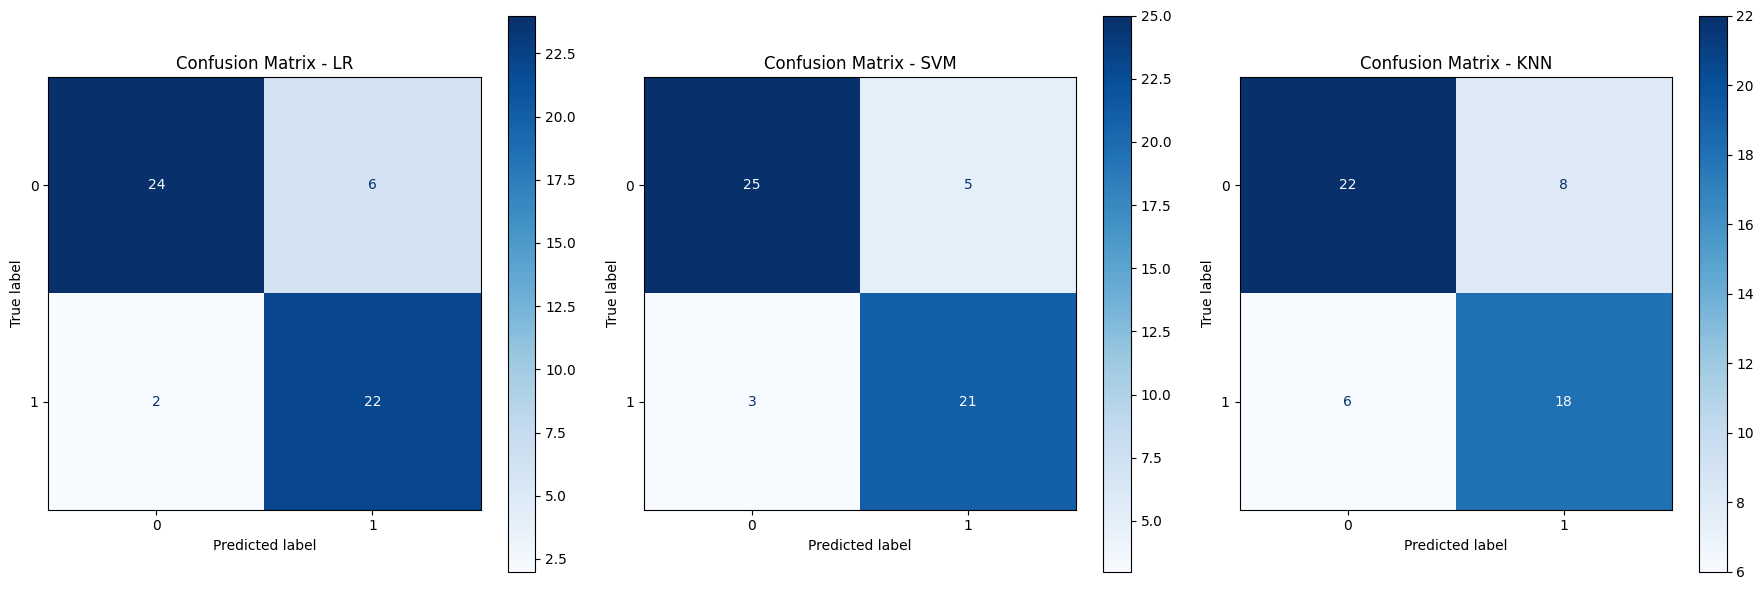

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Matriz de confusão LR
confLR = confusion_matrix(y_test1, y_predLR)
dispLR = ConfusionMatrixDisplay(confusion_matrix=confLR, display_labels=LRs[0].classes_)
dispLR.plot(ax=axes[0], cmap="Blues")
axes[0].set_title("Confusion Matrix - LR")

# Matriz de confusão SVM
confSVM = confusion_matrix(y_test1, y_predSVM)
dispSVM = ConfusionMatrixDisplay(confusion_matrix=confSVM, display_labels=SVMs[0].classes_)
dispSVM.plot(ax=axes[1], cmap="Blues")
axes[1].set_title("Confusion Matrix - SVM")

# Matriz de confusão KNN
confKNN = confusion_matrix(y_test1, y_predKNN)
dispKNN = ConfusionMatrixDisplay(confusion_matrix=confKNN, display_labels=KNNs[0].classes_)
dispKNN.plot(ax=axes[2], cmap="Blues")
axes[2].set_title("Confusion Matrix - KNN")

plt.tight_layout()
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The LR and SVM models showed very similar performance among all metrics for this dataset, while KNN presented bad results specially for balanced accuaracy and F-1 score. Perhaps with a larger amount of data, it will be possible to better distinguish the accuracy of LR and SVM. In general, the models had a higher number of false positives, which is less critical than misclassifying false negatives.
  </p>
</div>

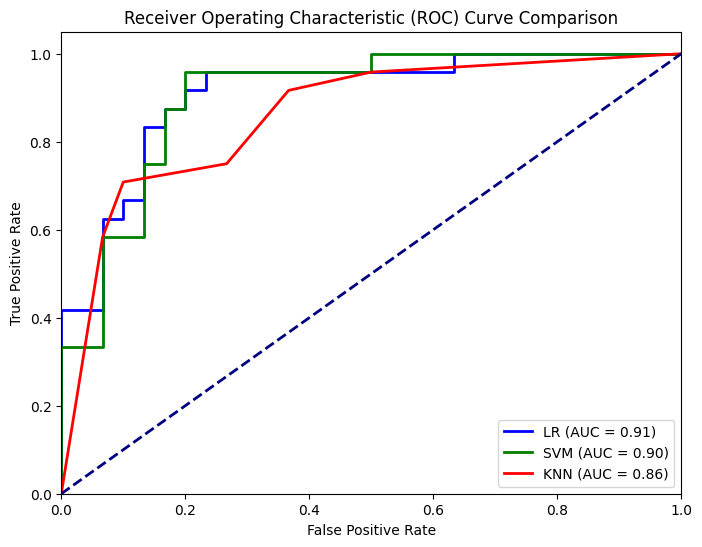

In [24]:
# Calculate ROC curve and AUC for each model
fprLR, tprLR, _ = roc_curve(y_test1, y_probLR)
roc_aucLR = auc(fprLR, tprLR)

fprSVM, tprSVM, _ = roc_curve(y_test1, y_probSVM)
roc_aucSVM = auc(fprSVM, tprSVM)

fprKNN, tprKNN, _ = roc_curve(y_test1, y_probKNN)
roc_aucKNN = auc(fprKNN, tprKNN)

# Plot all ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fprLR, tprLR, color='blue', lw=2, label=f'LR (AUC = {roc_aucLR:.2f})')
plt.plot(fprSVM, tprSVM, color='green', lw=2, label=f'SVM (AUC = {roc_aucSVM:.2f})')
plt.plot(fprKNN, tprKNN, color='red', lw=2, label=f'KNN (AUC = {roc_aucKNN:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc="lower right")
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    Looking at the AUC values, we can see that the performances of SVM and LR are truly similar, with almost overlapping ROC curves, which makes it difficult to determine the best model for this dataset. But KNN has clearly a worst result, since it is closer to the baseline.
  </p>
</div>

### df2 - segment.csv

In [31]:
y_predLR = LRs[1].predict(Xt_n2)
y_predSVM = SVMs[1].predict(Xt_n2)
y_predKNN = KNNs[1].predict(Xt_n2)

PredLR.append(y_predLR)
PredSVM.append(y_predSVM)
PredKNN.append(y_predKNN)

y_probLR = LRs[1].predict_proba(Xt_n2)
y_probSVM = SVMs[1].decision_function(Xt_n2)
y_probKNN = KNNs[1].predict_proba(Xt_n2)

# Logistic Regression
accLR = accuracy_score(y_test2, y_predLR)
lossLR = log_loss(y_test2, y_probLR)
print(f"LR: Acc={accLR:.4f}, Log Loss={lossLR:.4f}")

# SVM
accSVM = accuracy_score(y_test2, y_predSVM)
lossSVM = log_loss(y_test2, y_probSVM)
print(f"SVM: Acc={accSVM:.4f}, Log Loss={lossSVM:.4f}")

# Random Forest
accKNN = accuracy_score(y_test2, y_predKNN)
lossKNN = log_loss(y_test2, y_probKNN)
print(f"KNN: Acc={accKNN:.4f}, Log Loss={lossKNN:.4f}")

LR: Acc=0.9654, Log Loss=0.1422
SVM: Acc=0.9719, Log Loss=0.0006
KNN: Acc=0.9524, Log Loss=0.5970


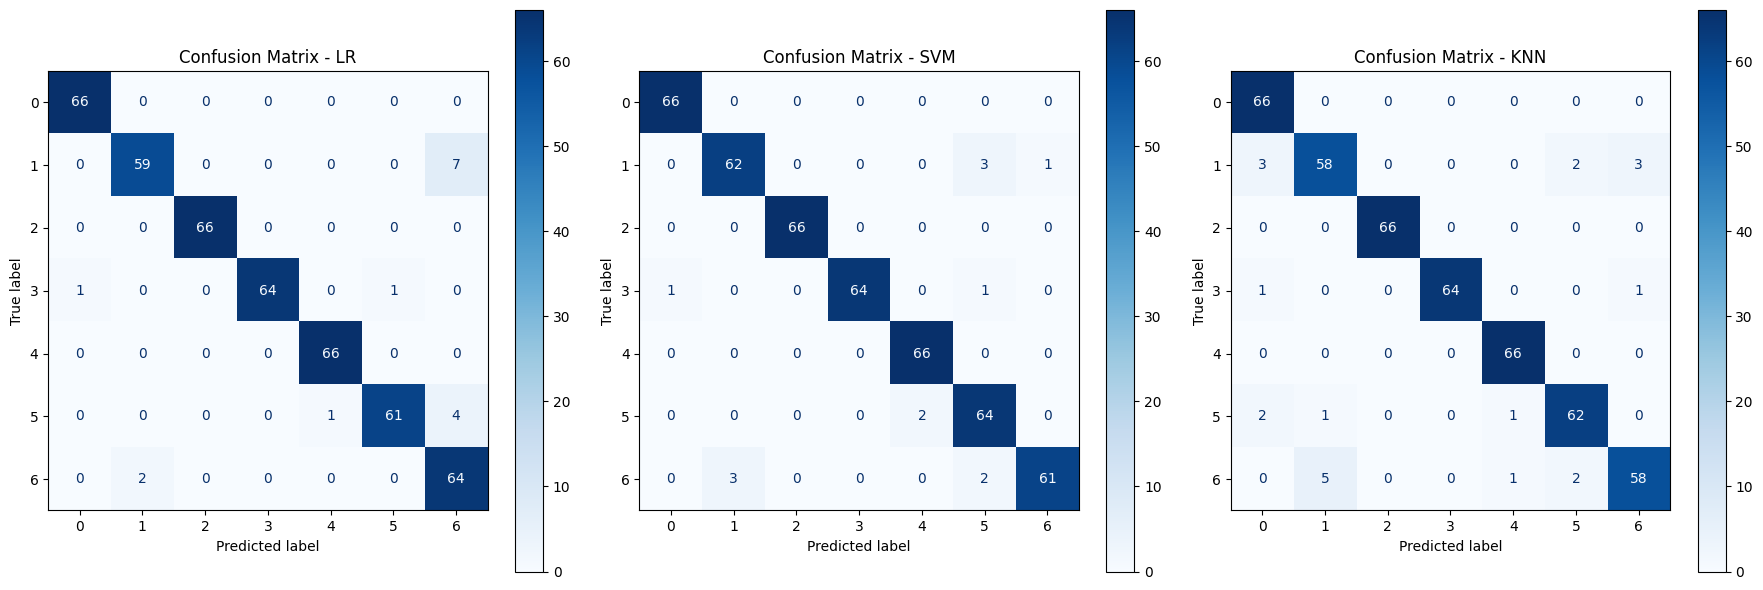

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Matriz de confusão LR
confLR = confusion_matrix(y_test2, y_predLR)
dispLR = ConfusionMatrixDisplay(confusion_matrix=confLR, display_labels=LRs[1].classes_)
dispLR.plot(ax=axes[0], cmap="Blues")
axes[0].set_title("Confusion Matrix - LR")

# Matriz de confusão SVM
confSVM = confusion_matrix(y_test2, y_predSVM)
dispSVM = ConfusionMatrixDisplay(confusion_matrix=confSVM, display_labels=SVMs[1].classes_)
dispSVM.plot(ax=axes[1], cmap="Blues")
axes[1].set_title("Confusion Matrix - SVM")

# Matriz de confusão KNN
confKNN = confusion_matrix(y_test2, y_predKNN)
dispKNN = ConfusionMatrixDisplay(confusion_matrix=confKNN, display_labels=KNNs[1].classes_)
dispKNN.plot(ax=axes[2], cmap="Blues")
axes[2].set_title("Confusion Matrix - KNN")

plt.tight_layout()
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    With a larger number of classes and data, we can observe a greater difference in the models' performance. SVM has the highest accuracy and the lowest Log Loss, indicating the best performance overall. Once again, KNN performs the worst. It is clear that the class that generated the most classification errors was class 1 (foliage), which was confused with classes 5 and 6 (cement and window), which was unexpected.
  </p>
</div>

### df3 - vehicle.csv

In [32]:
# Get predictions and probabilities
y_predLR = LRs[2].predict(Xt_n3)
y_predSVM = SVMs[2].predict(Xt_n3)
y_predKNN = KNNs[2].predict(Xt_n3)

PredLR.append(y_predLR)
PredSVM.append(y_predSVM)
PredKNN.append(y_predKNN)

y_probLR = LRs[2].predict_proba(Xt_n3)
y_probSVM = SVMs[2].decision_function(Xt_n3)
y_probKNN = KNNs[2].predict_proba(Xt_n3)

# Logistic Regression
accLR = accuracy_score(y_test3, y_predLR)
f1LR = f1_score(y_test3, y_predLR, average='macro')
print(f"LR: Acc={accLR:.4f}, F1={f1LR:.4f}")

# SVM
accSVM = accuracy_score(y_test3, y_predSVM)
f1SVM = f1_score(y_test3, y_predSVM, average='macro')
print(f"SVM: Acc={accSVM:.4f}, F1={f1SVM:.4f}")

# Random Forest
accKNN = accuracy_score(y_test3, y_predKNN)
f1KNN = f1_score(y_test3, y_predKNN, average='macro')
print(f"KNN: Acc={accKNN:.4f}, F1={f1KNN:.4f}")

LR: Acc=0.8412, F1=0.8388
SVM: Acc=0.8824, F1=0.8823
KNN: Acc=0.7294, F1=0.7257


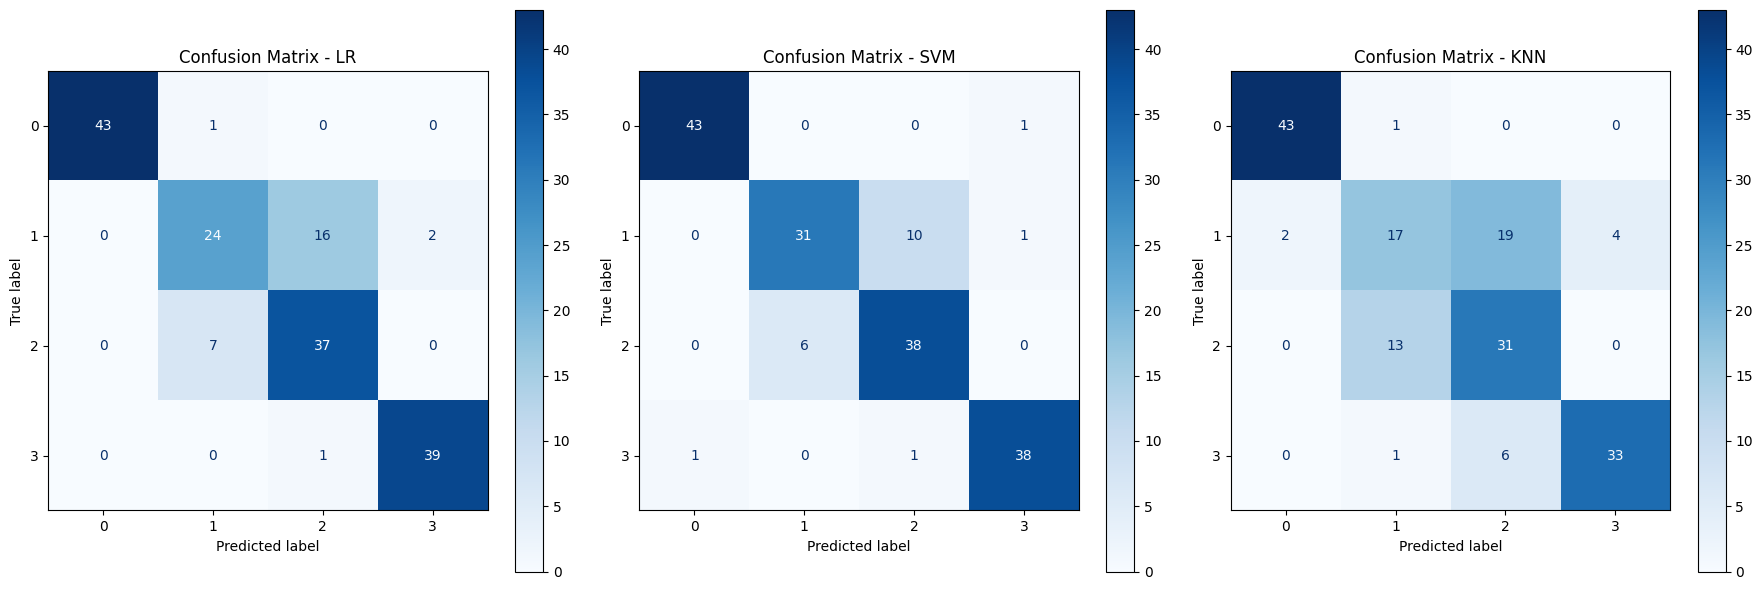

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Matriz de confusão LR
confLR = confusion_matrix(y_test3, y_predLR)
dispLR = ConfusionMatrixDisplay(confusion_matrix=confLR, display_labels=LRs[2].classes_)
dispLR.plot(ax=axes[0], cmap="Blues")
axes[0].set_title("Confusion Matrix - LR")

# Matriz de confusão SVM
confSVM = confusion_matrix(y_test3, y_predSVM)
dispSVM = ConfusionMatrixDisplay(confusion_matrix=confSVM, display_labels=SVMs[2].classes_)
dispSVM.plot(ax=axes[1], cmap="Blues")
axes[1].set_title("Confusion Matrix - SVM")

# Matriz de confusão KNN
confKNN = confusion_matrix(y_test3, y_predKNN)
dispKNN = ConfusionMatrixDisplay(confusion_matrix=confKNN, display_labels=KNNs[2].classes_)
dispKNN.plot(ax=axes[2], cmap="Blues")
axes[2].set_title("Confusion Matrix - KNN")

plt.tight_layout()
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    For dataset 3, the confusion matrix clearly reveals a strong conflict between classes 1 and 2 (Opel and Saab), which represent vehicles that are clearly different from the other classes, but with many similarities between them. Once again, the classification performance difference is evident, where the SVM model achieved the best performance followed by LR, and the KNN model is significantly worst. The latter achieved quite an unsatisfactory result for these two classes.
  </p>
</div>

## 2 Bonus : test statistique de significativité
1. Sur la base de performances moyennes obtenus sur les 3 datasets de l’exercice précédent,
sélectionnez les deux meilleures méthodes.

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    It is evident that SVM and LR are the best performing models.
  </p>
</div>

2. Réalisez un test de Wilcoxon pour établir si les différences de performances observées entre
ces deux meilleures méthodes sont significatives.

In [41]:
for i in range(3):

  # Perform Wilcoxon test on the collected scores
  stat, p_value = wilcoxon(PredLR[i], PredSVM[i])

  print(f"\nDataset {1+i}")
  print(f" Test statistic: {stat}")
  print(f" P-value: {p_value}")
  print(" -> Significant difference!" if p_value < 0.05 else "  -> No significant difference.")


Dataset 1
 Test statistic: 0.0
 P-value: 0.15729920705028502
  -> No significant difference.

Dataset 2
 Test statistic: 30.5
 P-value: 0.026753222254896562
 -> Significant difference!

Dataset 3
 Test statistic: 125.5
 P-value: 0.15939019818511424
  -> No significant difference.


3. Présentez et analysez les résultats obtenus.

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    There was no significant difference between the model in datasets 1 and 3, that is, LR and SVM are statistically equivalent, meaning their small metric differences do not translate into meaningful improvements from a statistical perspective.
  </p>
  <p>
    Only in dataset 2 there was seen a significant difference between them, and as said above above, SVM is the statiscally superior model.
  </p>
</div>

4. Réalisez un test de Friedman pour établir si les différences de performances observées entre les 3 méthodes sont significatives.

In [40]:
for i in range(3):

  # Perform Friedman test
  statistic, p_value = friedmanchisquare(PredLR[i], PredSVM[i], PredKNN[i])

  # Display results
  print(f"\nDataset {1+i}")
  print(f" Friedman test statistic: {statistic}")
  print(f" P-value: {p_value}")

  # Interpretation
  alpha = 0.05  # Significance level
  if p_value < alpha:
      print(" Significant differences exist between models (reject H0).")
  else:
      print(" No significant difference between models (fail to reject H0).")


Dataset 1
 Friedman test statistic: 0.7999999999998184
 P-value: 0.6703200460357002
 No significant difference between models (fail to reject H0).

Dataset 2
 Friedman test statistic: 14.865979381442779
 P-value: 0.0005914167130963675
 Significant differences exist between models (reject H0).

Dataset 3
 Friedman test statistic: 2.3473053892212734
 P-value: 0.30923533357863
 No significant difference between models (fail to reject H0).


5. Présentez et analysez les résultats obtenus

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    Surprinsingly, despite KNN having visibly worse performance on every dataset, the Friedman test do not confirm a significant statistical difference between it and the other models.
  </p>
  <p>
    Additionally, the difference found in dataset 2 can be caused by the superior results of SVM, as seen in the Wilcoxon test, not necessarely because of the terrible performance of KNN.
  </p>
</div>